### Zach Burgess, Brandon Lowery, Jason Martin
### COSC 526 Data Engineering
### Dr. Linder

In [1]:
# stage 0: import data
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("DataImport").getOrCreate()

df = spark.read.csv('data/train.csv', header=True, inferSchema=True, multiLine=True, escape='"')

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/18 21:49:51 WARN Utils: Your hostname, Bs-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.50.234 instead (on interface en0)
26/07/18 21:49:51 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/18 21:49:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
spark.sparkContext.setLogLevel("ERROR") #kills WARN level msg's from spark that are spamming the outputs when running on my macbook

In [3]:
# stage 1: short EDA
from pyspark.sql import functions as F

df.printSchema()

print(df.dtypes)

print(df.columns)

df.describe().show()

df.summary().show()

print('null check:')
df.select([F.count(F.when(df[c].isNull(), c)).alias(c) for c in df.columns]).show()

df.show(5, truncate=True)

root
 |-- id: string (nullable = true)
 |-- text: string (nullable = true)
 |-- author: string (nullable = true)

[('id', 'string'), ('text', 'string'), ('author', 'string')]
['id', 'text', 'author']
+-------+-------+--------------------+------+
|summary|     id|                text|author|
+-------+-------+--------------------+------+
|  count|  19579|               19579| 19579|
|   mean|   NULL|                NULL|  NULL|
| stddev|   NULL|                NULL|  NULL|
|    min|id00001|" Odenheimer, res...|   EAP|
|    max|id27971|you could not hop...|   MWS|
+-------+-------+--------------------+------+

+-------+-------+--------------------+------+
|summary|     id|                text|author|
+-------+-------+--------------------+------+
|  count|  19579|               19579| 19579|
|   mean|   NULL|                NULL|  NULL|
| stddev|   NULL|                NULL|  NULL|
|    min|id00001|" Odenheimer, res...|   EAP|
|    25%|   NULL|                NULL|  NULL|
|    50%|   NULL|

In [4]:
# stage 1: plot EDA
df2 = df.groupBy('author').count()
df2.plot.bar(x='author', y='count')

In [5]:
# stage 1: data prep
from pyspark.ml.feature import StopWordsRemover, Tokenizer

tokenizer = Tokenizer(inputCol='text', outputCol='words')
stop_word_remover = StopWordsRemover(inputCol='words', outputCol='filtered_words')

In [6]:
# stage 2: feature extraction
from pyspark.ml.feature import CountVectorizer, IDF, Normalizer

count_vectorizer = CountVectorizer(inputCol='filtered_words', outputCol='vectorized_features')
idf = IDF(inputCol='vectorized_features', outputCol='features')
normalizer = Normalizer(inputCol='features', outputCol='normalized_features')

In [7]:
# build pipeline and run
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=[tokenizer, stop_word_remover, count_vectorizer, idf, normalizer])
#final_df = pipeline.fit(df).transform(df)
pipeline_model = pipeline.fit(df)
final_df = pipeline_model.transform(df)

In [8]:
# confirm

final_df.printSchema()

print(final_df.dtypes)

print(final_df.columns)

print(final_df.describe().show())

print(final_df.summary().show())

final_df.show(5, truncate=True)

root
 |-- id: string (nullable = true)
 |-- text: string (nullable = true)
 |-- author: string (nullable = true)
 |-- words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- filtered_words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- vectorized_features: vector (nullable = true)
 |-- features: vector (nullable = true)
 |-- normalized_features: vector (nullable = true)

[('id', 'string'), ('text', 'string'), ('author', 'string'), ('words', 'array<string>'), ('filtered_words', 'array<string>'), ('vectorized_features', 'vector'), ('features', 'vector'), ('normalized_features', 'vector')]
['id', 'text', 'author', 'words', 'filtered_words', 'vectorized_features', 'features', 'normalized_features']
+-------+-------+--------------------+------+
|summary|     id|                text|author|
+-------+-------+--------------------+------+
|  count|  19579|               19579| 19579|
|   mean|   NULL|                NULL|  NULL|
| stdde

In [9]:
#stage 3 -- ML
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol='author', outputCol='label').fit(final_df)
data = indexer.transform(final_df)

labels = indexer.labels
print("label mapping:", dict(enumerate(labels)))

train, test = data.randomSplit([0.8, 0.2], seed=23)
print("train:", train.count(), " test:", test.count())

label mapping: {0: 'EAP', 1: 'MWS', 2: 'HPL'}
train: 15638  test: 3941


In [10]:
from pyspark.ml.classification import LogisticRegression, NaiveBayes, RandomForestClassifier
from pyspark.ml.clustering import KMeans

lr = LogisticRegression(featuresCol='normalized_features', labelCol='label', maxIter=500)
nb = NaiveBayes(featuresCol='normalized_features', labelCol='label')
kmeans = KMeans(featuresCol='normalized_features', k=5, seed=756)

lr_model = lr.fit(train)
nb_model = nb.fit(train)
km_model = kmeans.fit(train)

lr_preds = lr_model.transform(test)
nb_preds = nb_model.transform(test)
km_preds = km_model.transform(test)

km_preds.select('author','label', 'prediction').show(5)

+------+-----+----------+
|author|label|prediction|
+------+-----+----------+
|   MWS|  1.0|         0|
|   HPL|  2.0|         0|
|   MWS|  1.0|         0|
|   EAP|  0.0|         0|
|   EAP|  0.0|         0|
+------+-----+----------+
only showing top 5 rows


In [11]:
#display performance of our 3 models
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

acc_eval = MulticlassClassificationEvaluator(labelCol='label', metricName='accuracy')
f1_eval  = MulticlassClassificationEvaluator(labelCol='label', metricName='f1')

#this gives me a silhouette score for my k means clustering since f1 isn't used for it
mapping = {r['prediction']: r['label'] for r in
           km_preds.groupBy('prediction', 'label').count()
                   .orderBy('prediction', F.desc('count'))
                   .dropDuplicates(['prediction']).collect()}

km_scored = km_preds.withColumn(
    'prediction', F.create_map([F.lit(x) for kv in mapping.items() for x in kv])[F.col('prediction')])

print(f"{'LogisticRegression'} accuracy={acc_eval.evaluate(lr_preds)}  f1={f1_eval.evaluate(lr_preds)}")
print(f"{'NaiveBayes'} accuracy={acc_eval.evaluate(nb_preds)}  f1={f1_eval.evaluate(nb_preds)}")
print(f"{'KMeans'} accuracy={acc_eval.evaluate(km_scored)}  silhouette score={f1_eval.evaluate(km_scored)}")

LogisticRegression accuracy=0.7533620908398884  f1=0.7534169325845552
NaiveBayes accuracy=0.7980208069018015  f1=0.7971005061413722
KMeans accuracy=0.41182441004821113  silhouette score=0.24025557782467527


+-----+----+---+---+
|label| 0.0|1.0|2.0|
+-----+----+---+---+
|  0.0|1452|122| 49|
|  1.0| 255|926| 45|
|  2.0| 261| 64|767|
+-----+----+---+---+



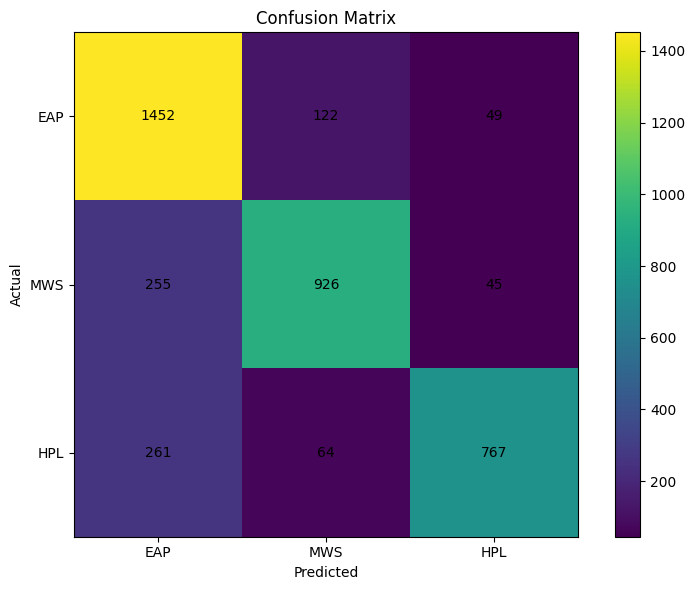

In [13]:
#confusion matrix
import matplotlib.pyplot as plt
import numpy as np

best_preds = nb_preds

cm_df = best_preds.groupBy('label').pivot('prediction').count().fillna(0).orderBy('label')
cm_df.show()

cm = np.array([[row[c] for c in cm_df.columns[1:]] for row in cm_df.collect()])

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.xticks(range(len(labels)), labels); plt.yticks(range(len(labels)), labels)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.colorbar(); plt.tight_layout(); plt.show()

In [14]:
vocab = pipeline_model.stages[2].vocabulary  # list of words, index-aligned with features
theta = nb_model.theta.toArray()  # shape: (num_classes, num_features)

top_n = 10

for i, author in enumerate(labels):
    top_word_idx = np.argsort(theta[i])[::-1][:top_n]
    top_words = [vocab[i] for i in top_word_idx]
    print(f"{author}: {top_words}")

EAP: ['upon', 'one', 'however,', 'said', 'little', 'and,', 'made', 'even', 'thus', 'first']
MWS: ['one', 'me,', 'yet', 'might', 'me.', 'even', 'raymond', 'must', 'love', 'shall']
HPL: ['.', 'old', 'one', 'seemed', 'like', 'saw', 'things', 'though', "an'", 'never']


In [ ]:
#findings, learning, next steps, etc:

#Naive Bayes model was the most successful model we ran. We believe this is likely due to two factors: First,
#naive bayes is known to be good for text classification problems and Second, it is optimized better from the standard call.
#We believe that our regression could have competed better with the Naive Bayes model with more optimization, however
#the naive bayes model performed well enough already so we did not persue this. K means clustering might have potential with the addition of PCA
#and other refinement techniques.